# Rede Percepetron

O estudo teórico sobre redes Peceptron está disponível em slides. Clique [aqui](https://github.com/pedrothiag/intelligent-systems/blob/main/slides/06_perceptron.pdf) para acessar os slides.

### Implementação Manual

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [2]:
# ── Configurações de Plotagem ────────────────────────────────────────────────
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 5)

In [12]:
# ── Classe Perceptron ────────────────────────────────────────────────────────
class myPerceptron:
    def __init__(self):
        self.weights = None
        self.epochs_run = 0
        self.converged = False
    
    # Função de treinamento do Perceptron
    def fit(self, X_raw, yd, eta, max_epochs):
        X = np.column_stack((-1.0*np.ones(X_raw.shape[0]), X_raw))      # Adiciona o termo de bias (coluna de -1)
        # X.shape[0] --> quantidade de linhas
        # X.shape[1] --> quantidade de colunas
        #     | -1 x1(1) x2(1) ... xn(1) 
        #     | -1 x1(2) x2(2) ... xn(2)
        # X = | .........................
        #     | -1 x1(p) x2(p) ... xn(p)
        w = 0.1*np.random.randn(X.shape[1])                             # Inicializa os pesos com valores aleatórios pequenos
        n_samples = X.shape[0]                                          # Número de amostras
        epochs = 0                                                      # Contador de épocas
        error = True                                                    # Flag de erro (inicialmente True para entrar no loop)

        indexes = np.arange(n_samples)                                  # Índices para embaralhar as amostras

        # Loop de treinamento do Perceptron
        while (error and epochs <= max_epochs):
            error = False
            np.random.shuffle(indexes)                                  # Embaralha os índices para garantir
            for idx in indexes:
                u = np.dot(w,X[idx,:])
                y = np.sign(u)
                if y != yd[idx]:
                    w = w + eta*(yd[idx] - y)*X[idx,:]
                    error = True
            epochs = epochs + 1

        self.weights = w
        self.epochs_run = epochs
        self.converged = not error
    
    # Função de predição do Perceptron
    def predict(self, X_raw):
        X = np.column_stack((-1.0*np.ones(X_raw.shape[0]), X_raw))
        number_samples = X.shape[0]
        y_pred = np.zeros(number_samples)
        for idx in range(number_samples):
            y_pred[idx] = np.sign(np.dot(self.weights,X[idx,:]))
        return y_pred

In [14]:
# ── Dataset ──────────────────────────────────────────────────────────────────
iris = load_iris()
X = iris.data[:100, :2]  # setosa (0..49) + versicolor (50..99), 2 features
y = np.where(iris.target[:100] == 0, 1, -1)   # setosa → +1, versicolor → -1

print(f"Freatures: {iris.feature_names[:2]}")

Freatures: ['sepal length (cm)', 'sepal width (cm)']


Text(0, 0.5, 'sepal width (cm)')

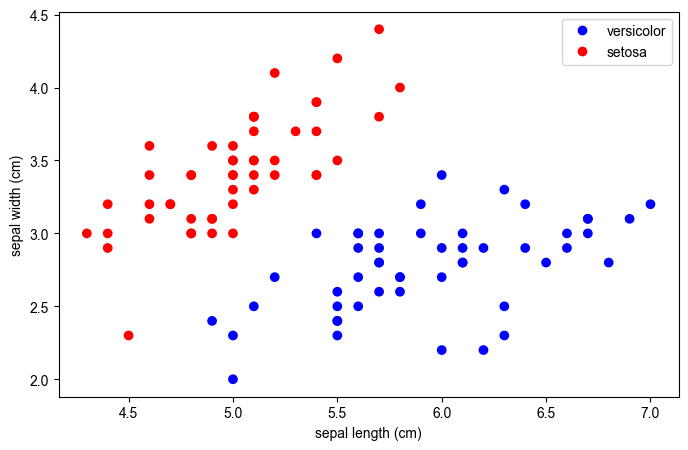

In [17]:
plt.figure()
sc = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
plt.legend(handles=sc.legend_elements()[0], labels=['versicolor', 'setosa'])
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])

Utilizando todas as classes:

Text(0, 0.5, 'sepal width (cm)')

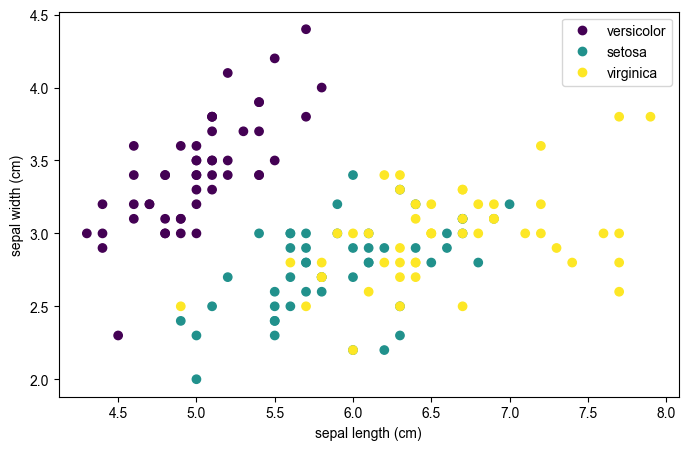

In [22]:
X_total = iris.data[:, :2]
y_total = iris.target

plt.figure()
sc = plt.scatter(X_total[:, 0], X_total[:, 1], c=y_total)
plt.legend(handles=sc.legend_elements()[0], labels=['versicolor', 'setosa', 'virginica'])
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])

In [23]:
# ── Divisão do Dataset ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [30]:
# ── Treino ───────────────────────────────────────────────────────────────────
p = myPerceptron()
p.fit(X_train, y_train, eta=0.01, max_epochs=100)

print(f"Convergiu:   {p.converged}")
print(f"Épocas:      {p.epochs_run}")
print(f"Pesos:       {p.weights}")

Convergiu:   True
Épocas:      2
Pesos:       [ 0.00641561 -0.09043584  0.06146472]


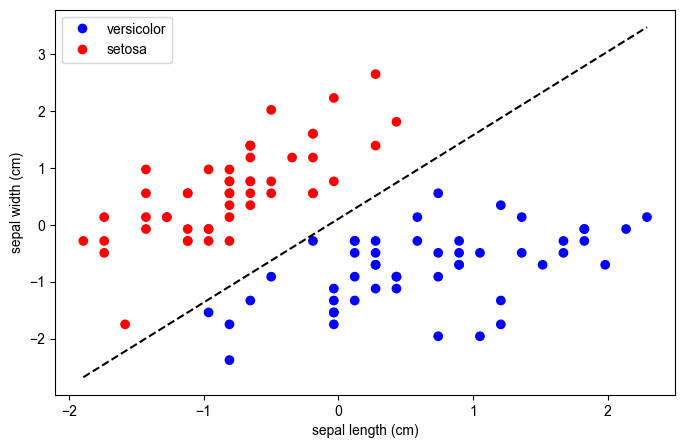

In [31]:
# ── Visualização da Fronteira de Decisão ───────────────────────────────────────
X_norm = scaler.transform(X)
x1 = np.linspace(X_norm[:, 0].min(), X_norm[:, 0].max(), 100)
x2 = (p.weights[0] - p.weights[1]*x1) / p.weights[2]

plt.figure()
plt.plot(x1,x2, 'k--')
sc = plt.scatter(X_norm[:, 0], X_norm[:, 1], c=y, cmap='bwr')
plt.legend(handles=sc.legend_elements()[0], labels=['versicolor', 'setosa'])
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()

In [27]:
# ── Teste ───────────────────────────────────────────────────────────────────
y_pred = p.predict(X_test)
confusionMatriz = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
print(confusionMatriz)

Matriz de Confusão:
[[10  0]
 [ 0 10]]


### Implementação Utilizando a `sklearn`

In [39]:
from sklearn.linear_model import Perceptron

# ── Treinamento do Perceptron ───────────────────────────────────────────────
p_skl = Perceptron(eta0=0.01, max_iter=100)
p_skl.fit(X_train, y_train)

print(f"Convergiu:  {p_skl.n_iter_ < p_skl.max_iter}")
print(f"Épocas:     {p_skl.n_iter_}")
print(f"Pesos:      {p_skl.coef_}")
print(f"Bias:       {p_skl.intercept_}")

Convergiu:  True
Épocas:     6
Pesos:      [[-0.03065441  0.02168639]]
Bias:       [-0.01]


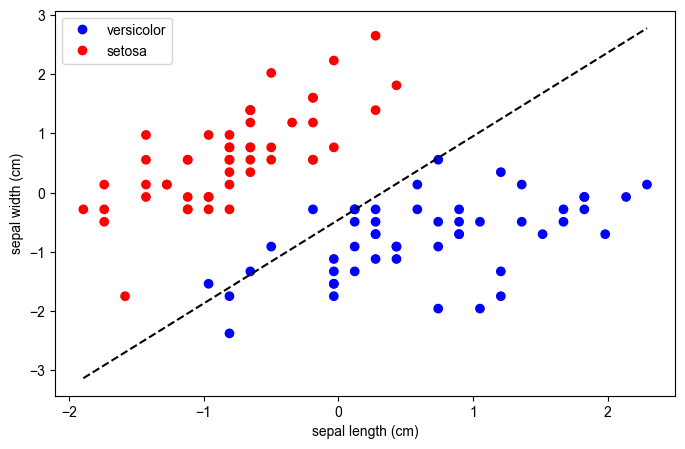

In [42]:
# ── Visualização da Fronteira de Decisão ───────────────────────────────────────
X_norm = scaler.transform(X)
x1 = np.linspace(X_norm[:, 0].min(), X_norm[:, 0].max(), 100)
x2 = (p_skl.intercept_ - p_skl.coef_[0][0]*x1) / p_skl.coef_[0][1]
plt.figure()
plt.plot(x1,x2, 'k--')
sc = plt.scatter(X_norm[:, 0], X_norm[:, 1], c=y, cmap='bwr')
plt.legend(handles=sc.legend_elements()[0], labels=['versicolor', 'setosa'])
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()

In [43]:
# ── Teste ───────────────────────────────────────────────────────────────────
y_pred = p.predict(X_test)
confusionMatriz = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
print(confusionMatriz)

Matriz de Confusão:
[[10  0]
 [ 0 10]]
